In [3]:
!pip install -q chronos-forecasting

# VERİ

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import ChronosPipeline

np.random.seed(0)
torch.manual_seed(0)

data = pd.read_csv("autism.csv", parse_dates=["tarih"]).set_index("tarih")
y = data["bdt"].resample("MS").mean().interpolate().dropna()
y.index.freq = "MS"

H = 36
train, test = y.iloc[:-H], y.iloc[-H:]
results = {}

print(y.shape, train.shape, test.shape)
y.head()

(264,) (228,) (36,)


,bdt
tarih,
2003-09-01,33.604000
2003-10-01,35.010000
2003-11-01,36.823333
2003-12-01,38.210000
2004-01-01,38.492500


In [5]:
gamma = sm.tsa.acovf(train.values, nlag=36, fft=True)
rho = sm.tsa.acf(train.values, nlags=36, fft=True)
phi = sm.tsa.pacf(train.values, nlags=36)

pd.DataFrame({"gamma_k": gamma[:13], "rho_k": rho[:13], "phi_kk": phi[:13]})

,gamma_k,rho_k,phi_kk
0,95.615174,1.000000,1.000000
1,92.453263,0.966931,0.971190
2,87.400906,0.914090,-0.370341
3,82.882633,0.866836,0.219816
4,80.144112,0.838194,0.224114
5,78.588192,0.821922,0.017514
6,77.148527,0.806865,-0.016290
7,75.471859,0.789329,0.059549
8,74.062311,0.774587,0.128278
9,73.917322,0.773071,0.236943


In [6]:
d1 = train.diff().dropna()
d12 = d1.diff(12).dropna()

pd.DataFrame(
    [
        {"seri": "y_t", "adf": adfuller(train)[0], "p": adfuller(train)[1]},
        {"seri": "d1_y_t", "adf": adfuller(d1)[0], "p": adfuller(d1)[1]},
        {"seri": "d12_d1_y_t", "adf": adfuller(d12)[0], "p": adfuller(d12)[1]},
    ]
).set_index("seri")

,adf,p
seri,,
y_t,-1.734122,4.136230e-01
d1_y_t,-3.736350,3.629965e-03
d12_d1_y_t,-8.450743,1.665048e-13


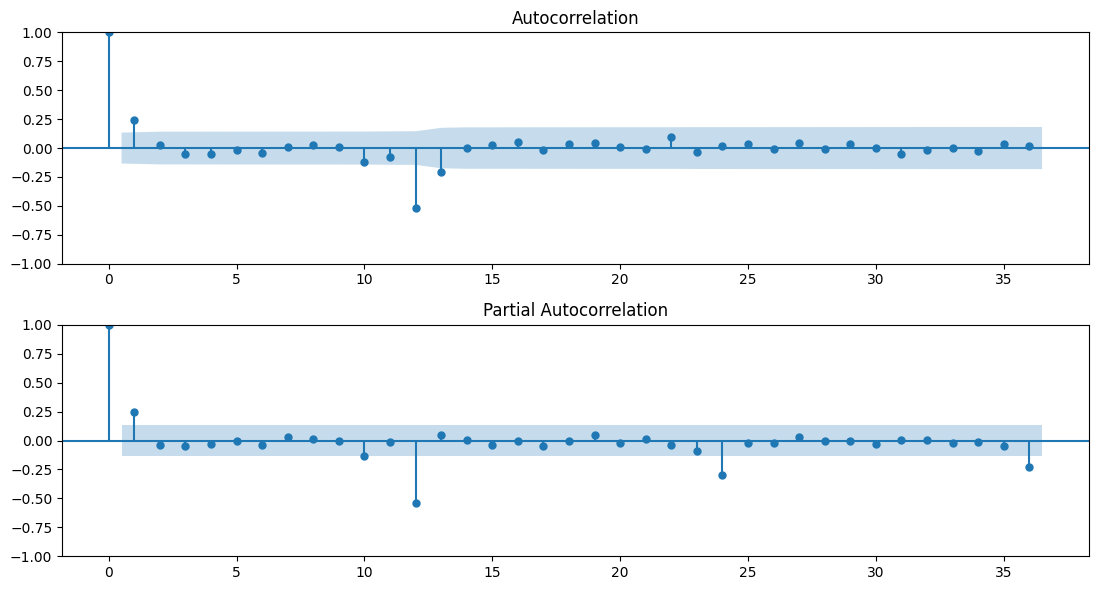

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
sm.graphics.tsa.plot_acf(d12, lags=36, ax=ax[0])
sm.graphics.tsa.plot_pacf(d12, lags=36, ax=ax[1], method="ywm")
plt.tight_layout()
plt.show()

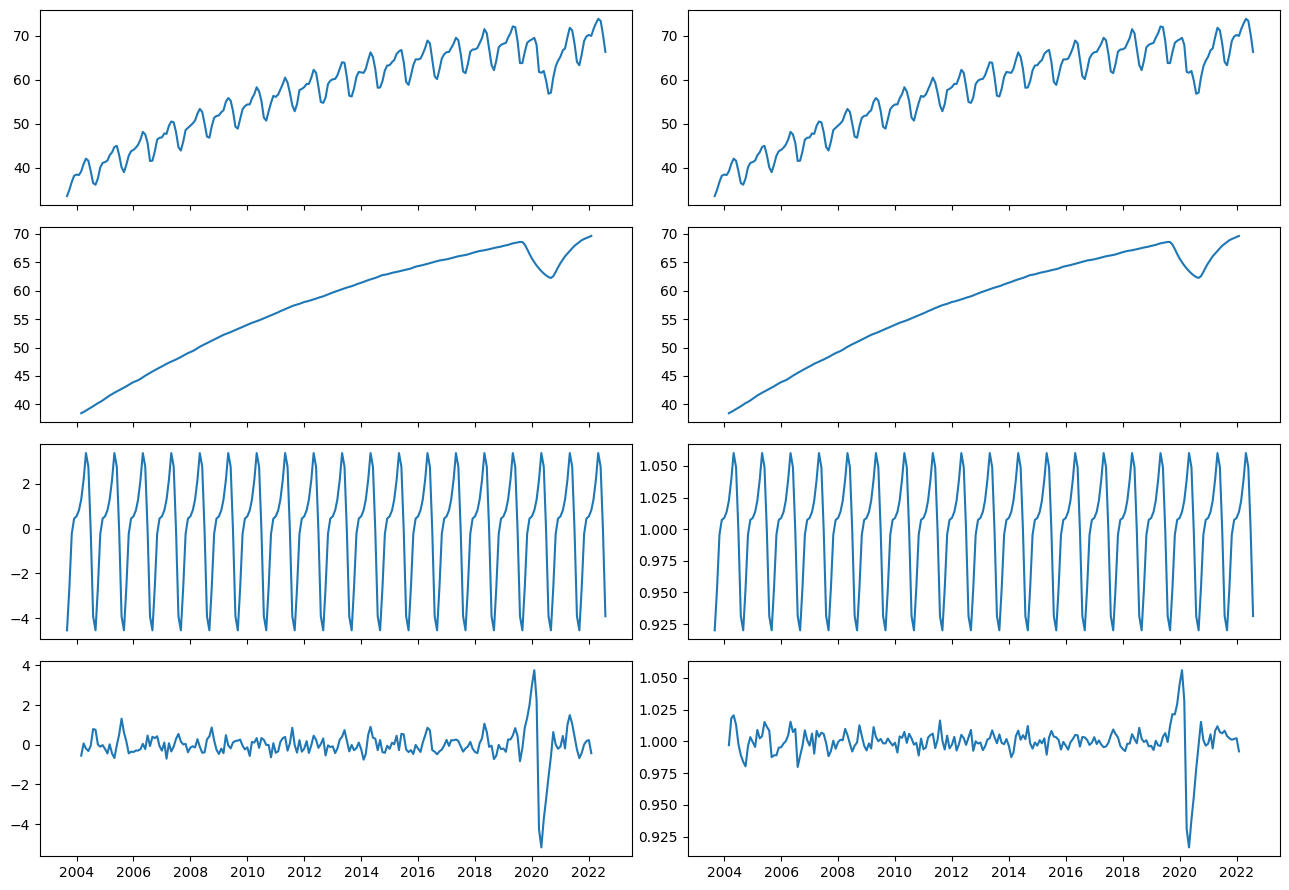

In [8]:
add = seasonal_decompose(train, model="additive", period=12)
mul = seasonal_decompose(train, model="multiplicative", period=12)

fig, ax = plt.subplots(4, 2, figsize=(13, 9), sharex=True)
for j, dec in enumerate([add, mul]):
    ax[0, j].plot(dec.observed)
    ax[1, j].plot(dec.trend)
    ax[2, j].plot(dec.seasonal)
    ax[3, j].plot(dec.resid)
plt.tight_layout()
plt.show()

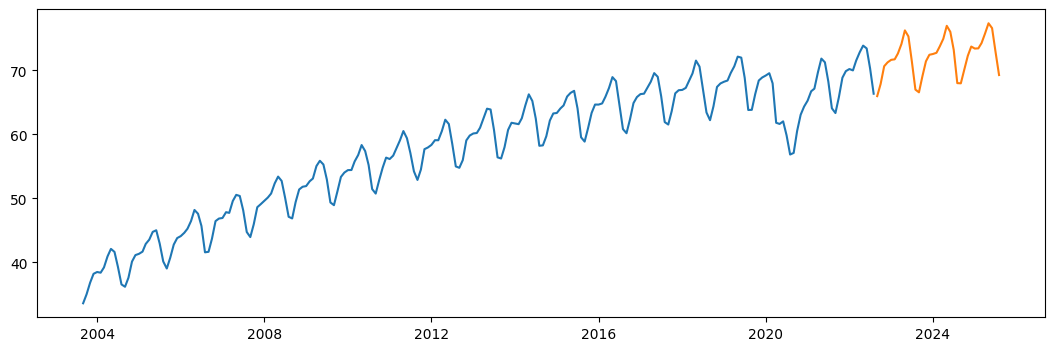

In [9]:
plt.figure(figsize=(13, 4))
plt.plot(train.index, train.values)
plt.plot(test.index, test.values)
plt.show()

# MODEL

## Deterministik

In [10]:
dp = DeterministicProcess(index=train.index, constant=True, order=1, seasonal=True)
X_tr = dp.in_sample()
X_te = dp.out_of_sample(H)

det = sm.OLS(train.values, X_tr.values).fit()
results["Deterministik"] = pd.Series(det.predict(X_te.values), index=test.index)
results["Deterministik"].head()

,0
tarih,
2022-09-01,68.536358
2022-10-01,70.546130
2022-11-01,73.071525
2022-12-01,73.927736
2023-01-01,74.174078


## Stokastik

In [11]:
sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
pred = sarima.get_forecast(H).predicted_mean
pred.index = test.index

results["Stokastik"] = pred
results["Stokastik"].head()

,predicted_mean
tarih,
2022-09-01,65.961841
2022-10-01,68.183971
2022-11-01,70.762380
2022-12-01,71.616963
2023-01-01,71.925477


## ShallowML

In [12]:
L = 24
dtrain = train.diff().dropna().values


def lag_matrix(v, lags):
    X = np.column_stack([v[i:len(v) - lags + i] for i in range(lags)])
    return X, v[lags:]


X, target = lag_matrix(dtrain, L)
rf = RandomForestRegressor(n_estimators=500, random_state=0).fit(X, target)

window = list(dtrain[-L:])
level = train.values[-1]
path = []
for _ in range(H):
    delta = rf.predict(np.array(window[-L:]).reshape(1, -1))[0]
    level = level + delta
    path.append(level)
    window.append(delta)

results["ShallowML"] = pd.Series(path, index=test.index)
results["ShallowML"].head()

,0
tarih,
2022-09-01,65.851705
2022-10-01,68.133663
2022-11-01,70.522657
2022-12-01,71.412579
2023-01-01,71.753892


## DeepML

In [13]:
mu, sd = dtrain.mean(), dtrain.std()
z = (dtrain - mu) / sd
Xz, tz = lag_matrix(z, L)
Xt = torch.tensor(Xz, dtype=torch.float32).unsqueeze(-1)
tt = torch.tensor(tz, dtype=torch.float32).unsqueeze(-1)


class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.encoder = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.encoder(x)
        return self.head(out[:, -1, :])


net = LSTMForecaster()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
mse = nn.MSELoss()

for epoch in range(400):
    opt.zero_grad()
    loss = mse(net(Xt), tt)
    loss.backward()
    opt.step()

net.eval()
window = list(z[-L:])
level = train.values[-1]
path = []
with torch.no_grad():
    for _ in range(H):
        x = torch.tensor(np.array(window[-L:]), dtype=torch.float32).view(1, L, 1)
        dz = net(x).item()
        level = level + dz * sd + mu
        path.append(level)
        window.append(dz)

results["DeepML"] = pd.Series(path, index=test.index)
print(loss.item())
results["DeepML"].head()

0.0634971633553505


,0
tarih,
2022-09-01,66.128883
2022-10-01,68.539379
2022-11-01,70.648859
2022-12-01,71.139216
2023-01-01,71.506382


## Foundation

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map=device, torch_dtype=torch.float32
)

context = torch.tensor(train.values, dtype=torch.float32)
samples = pipeline.predict(context, prediction_length=H, num_samples=100)

results["Foundation"] = pd.Series(np.median(samples[0].numpy(), axis=0), index=test.index)
results["Foundation"].head()

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

,0
tarih,
2022-09-01,66.111244
2022-10-01,68.637794
2022-11-01,71.585426
2022-12-01,72.006516
2023-01-01,72.427605


## Headed

In [15]:
C = 64
v = train.values.astype(np.float32)
windows = np.stack([v[i:i + C] for i in range(len(v) - C)])
labels = v[C:]


def encode(batch):
    with torch.no_grad():
        emb, scale = pipeline.embed(torch.tensor(batch, dtype=torch.float32))
    return emb.mean(dim=1).float().numpy(), scale.float().cpu().numpy()


Z, S = [], []
for i in range(0, len(windows), 64):
    e, s = encode(windows[i:i + 64])
    Z.append(e)
    S.append(s)
Z, S = np.concatenate(Z), np.concatenate(S)

head = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 13)))
head.fit(Z, labels / S)

buffer = list(v)
path = []
for _ in range(H):
    e, s = encode(np.array(buffer[-C:], dtype=np.float32).reshape(1, -1))
    nxt = float(head.predict(e)[0] * s[0])
    path.append(nxt)
    buffer.append(nxt)

results["Headed"] = pd.Series(path, index=test.index)
print(Z.shape)
results["Headed"].head()

(164, 512)


,0
tarih,
2022-09-01,66.493186
2022-10-01,67.991523
2022-11-01,70.573052
2022-12-01,72.435927
2023-01-01,71.284367


# DEĞERLENDİRME

In [16]:
def score(actual, pred):
    return {
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAPE": np.mean(np.abs((actual - pred) / actual)) * 100,
    }


scores = pd.DataFrame(
    {name: score(test.values, np.asarray(pred, dtype=float)) for name, pred in results.items()}
).T
scores

,MAE,RMSE,MAPE
Deterministik,3.233148,3.327739,4.491738
Stokastik,0.683212,0.809842,0.943962
ShallowML,0.978049,1.156519,1.351530
DeepML,0.843724,0.990602,1.170765
Foundation,3.313245,4.086846,4.561860
Headed,2.769262,3.793772,3.804080


In [17]:
forecasts = pd.DataFrame(results, index=test.index)
forecasts.insert(0, "Gercek", test.values)
forecasts

,Gercek,Deterministik,Stokastik,ShallowML,DeepML,Foundation,Headed
tarih,,,,,,,
2022-09-01,65.990000,68.536358,65.961841,65.851705,66.128883,66.111244,66.493186
2022-10-01,67.890000,70.546130,68.183971,68.133663,68.539379,68.637794,67.991523
2022-11-01,70.665000,73.071525,70.762380,70.522657,70.648859,71.585426,70.573052
2022-12-01,71.270000,73.927736,71.616963,71.412579,71.139216,72.006516,72.435927
2023-01-01,71.662000,74.174078,71.925477,71.753892,71.506382,72.427605,71.284367
2023-02-01,71.745000,74.556981,72.366618,72.510608,72.215987,72.848694,69.149822
2023-03-01,72.655000,75.232841,72.912785,72.897134,73.311791,73.690872,67.036766
2023-04-01,74.143333,76.277051,73.520957,74.181592,74.890272,74.533058,66.663532
2023-05-01,76.266000,77.598779,74.857418,75.408981,76.230726,76.217422,66.741059


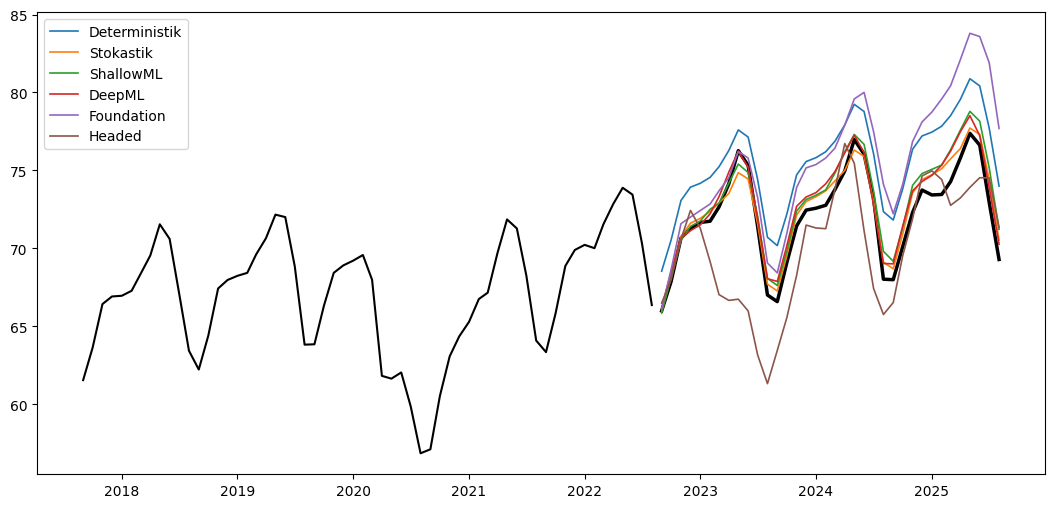

In [18]:
plt.figure(figsize=(13, 6))
plt.plot(train.index[-60:], train.values[-60:], color="black")
plt.plot(test.index, test.values, color="black", linewidth=2.5)
for name, pred in results.items():
    plt.plot(test.index, pred.values, linewidth=1.2, label=name)
plt.legend()
plt.show()

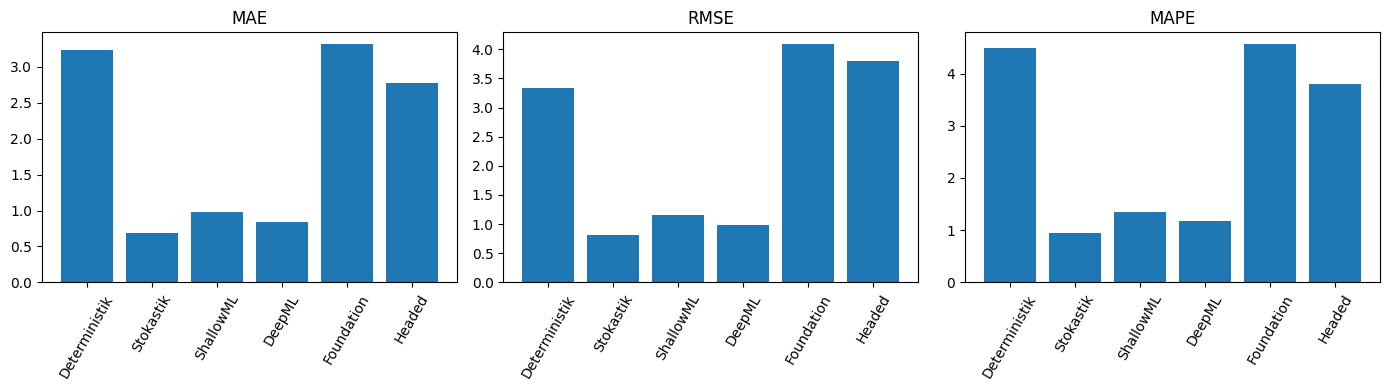

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for j, metric in enumerate(["MAE", "RMSE", "MAPE"]):
    ax[j].bar(scores.index, scores[metric])
    ax[j].set_title(metric)
    ax[j].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

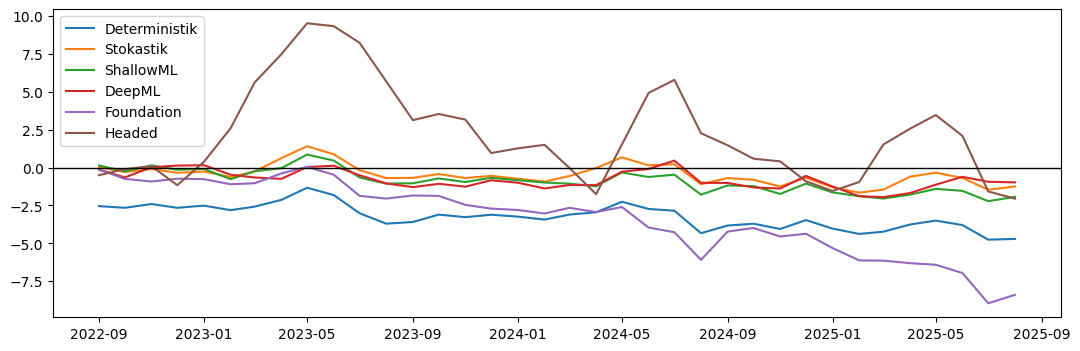

,count,mean,std,min,25%,50%,75%,max
Deterministik,36.0,-3.233148,0.798957,-4.760486,-3.769245,-3.176686,-2.657334,-1.332779
Stokastik,36.0,-0.462735,0.674048,-1.656558,-0.753852,-0.582242,-0.151181,1.408582
ShallowML,36.0,-0.889302,0.749865,-2.218969,-1.438951,-0.971275,-0.305472,0.857019
DeepML,36.0,-0.792742,0.602441,-1.951490,-1.184231,-0.959015,-0.421567,0.459367
Foundation,36.0,-3.310547,2.430363,-8.959645,-4.740911,-2.754474,-1.086738,0.048578
Headed,36.0,2.180966,3.148239,-2.054149,-0.044386,1.511399,3.483756,9.524941


In [20]:
residuals = pd.DataFrame(
    {name: test.values - np.asarray(pred, dtype=float) for name, pred in results.items()},
    index=test.index,
)

plt.figure(figsize=(13, 4))
for name in residuals.columns:
    plt.plot(residuals.index, residuals[name], label=name)
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.show()

residuals.describe().T